In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

print("--- LOADING PROCESSED DATA ---")
# İlk dosyada saatlerce uğraşıp kaydettiğimiz o hazır veriyi okuyoruz!
df = pd.read_csv('senate_processed_data_with_alpha.csv')

# Tarih formatını güvenceye alıyoruz
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print(f"Data loaded successfully! Shape: {df.shape}")

--- LOADING PROCESSED DATA ---
Data loaded successfully! Shape: (4699, 24)


In [4]:
# We train a Random Forest classifier to learn which pre-trade feature
# combinations are associated with statistically abnormal post-trade outcomes.
# The model is evaluated with stratified cross-validation to ensure that
# the class imbalance does not inflate performance estimates.
#
# Features used (all observable before the trade outcome is known):
#   is_buy_order  — direction of the transaction
#   log_volume    — log-transformed transaction size
#   year          — capture regulatory-environment shifts over time
#   month         — seasonality (earnings seasons, legislative calendar)
#   is_proxy      — whether the account is distanced from the senator
#   is_option     — whether the instrument is an option (highest precision required)
#   sector_code   — encoded industry sector of the traded asset
# =============================================================================

print("\n--- STEP 5: TRAINING AND EVALUATING RANDOM FOREST CLASSIFIER ---")

MODEL_FEATURES = [
    'is_buy_order',
    'log_volume',
    'year',
    'month',
    'is_proxy',
    'is_option',
    'sector_code',
]

ml_df = df.dropna(subset=['is_suspicious'] + MODEL_FEATURES)

X = ml_df[MODEL_FEATURES]
y = ml_df['is_suspicious']

print(f"Training set size: {len(ml_df)} records | Features: {len(MODEL_FEATURES)}")

if len(ml_df) > 10 and y.nunique() > 1:

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # class_weight='balanced' inversely weights classes by frequency,
    # which is essential here because suspicious transactions are rare
    rf_model = RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    rf_model.fit(X_train, y_train)

    y_pred = rf_model.predict(X_test)
    y_prob = rf_model.predict_proba(X_test)[:, 1]

    print("\n[Classification Report]")
    print(classification_report(y_test, y_pred, zero_division=0))
    print(f"ROC-AUC Score           : {roc_auc_score(y_test, y_prob):.4f}")

    # 5-fold stratified cross-validation gives a more reliable estimate
    # than a single train/test split, especially with small datasets
    cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='roc_auc')
    print(f"5-Fold CV Mean ROC-AUC  : {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

    print("\n[Feature Importance]")
    importance_df = pd.DataFrame({
        'Feature'   : MODEL_FEATURES,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    for _, row in importance_df.iterrows():
        bar = '█' * int(row['Importance'] * 60)
        print(f"  {row['Feature']:<15} {bar} {row['Importance']:.4f}")

    # Attach predicted suspicion probability back to the main dataframe
    # for use in downstream network visualization
    prob_series = rf_model.predict_proba(df[MODEL_FEATURES].fillna(0))[:, 1]
    df['suspicion_probability'] = prob_series

else:
    print("Not enough data to train the classifier. Assigning uniform probability.")
    df['suspicion_probability'] = 0.5


--- STEP 5: TRAINING AND EVALUATING RANDOM FOREST CLASSIFIER ---
Training set size: 4699 records | Features: 7

[Classification Report]
              precision    recall  f1-score   support

           0       0.85      0.63      0.72       751
           1       0.27      0.56      0.37       189

    accuracy                           0.61       940
   macro avg       0.56      0.59      0.55       940
weighted avg       0.73      0.61      0.65       940

ROC-AUC Score           : 0.6201
5-Fold CV Mean ROC-AUC  : 0.3794 (+/- 0.2426)

[Feature Importance]
  year            █████████████████████ 0.3581
  month           ███████████████ 0.2619
  sector_code     ████████ 0.1428
  log_volume      ███████ 0.1169
  is_buy_order    ███ 0.0640
  is_proxy        ███ 0.0564
  is_option        0.0000



--- STEP 6: STATISTICAL HYPOTHESIS TESTING (PROXY vs. SELF ACCOUNTS) ---
Self-executed records  : n = 745
Proxy-executed records : n = 3731

Mean alpha (self)  : 0.1387%
Mean alpha (proxy) : 0.1790%
T-statistic        : 0.1279
P-value (two-tail) : 0.8982

Decision (α=0.05): Fail to reject H0. No statistically significant
difference in market-adjusted returns between account types.


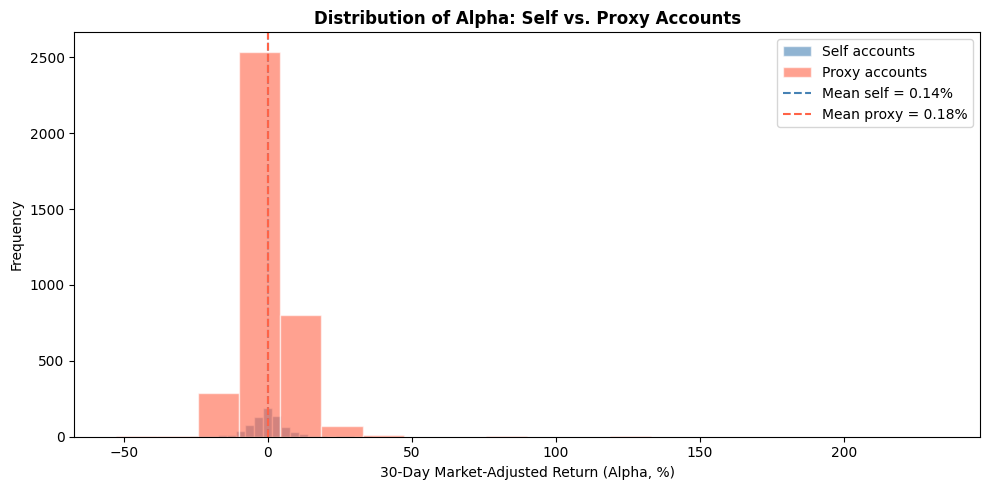

In [6]:
# We test whether transactions executed through proxy accounts (spouse, child,
# joint) generate systematically different alphas than self-executed trades.
#
# H0: mean(alpha_proxy) = mean(alpha_self)
# H1: mean(alpha_proxy) ≠ mean(alpha_self)
#
# A significant difference would suggest that proxy accounts are used
# strategically, potentially to obscure the link between the senator
# and the informational advantage being exploited.
#
# We use Welch's t-test (equal_var=False) because there is no a priori
# reason to assume equal variance across the two groups.
# =============================================================================

print("\n--- STEP 6: STATISTICAL HYPOTHESIS TESTING (PROXY vs. SELF ACCOUNTS) ---")
import scipy.stats as stats
self_alpha  = df[df['is_proxy'] == 0]['alpha'].dropna()
proxy_alpha = df[df['is_proxy'] == 1]['alpha'].dropna()

print(f"Self-executed records  : n = {len(self_alpha)}")
print(f"Proxy-executed records : n = {len(proxy_alpha)}")

if len(self_alpha) > 1 and len(proxy_alpha) > 1:
    t_stat, p_val = stats.ttest_ind(proxy_alpha, self_alpha, equal_var=False)

    print(f"\nMean alpha (self)  : {self_alpha.mean():.4f}%")
    print(f"Mean alpha (proxy) : {proxy_alpha.mean():.4f}%")
    print(f"T-statistic        : {t_stat:.4f}")
    print(f"P-value (two-tail) : {p_val:.4f}")

    alpha_level = 0.05
    if p_val < alpha_level:
        print(f"\nDecision (α={alpha_level}): Reject H0. Proxy and self accounts exhibit")
        print("statistically significant differences in market-adjusted returns,")
        print("consistent with strategic use of distanced trading accounts.")
    else:
        print(f"\nDecision (α={alpha_level}): Fail to reject H0. No statistically significant")
        print("difference in market-adjusted returns between account types.")

    # Visualize the alpha distributions for both groups
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(self_alpha,  bins=20, alpha=0.6, label='Self accounts',  color='steelblue', edgecolor='white')
    ax.hist(proxy_alpha, bins=20, alpha=0.6, label='Proxy accounts', color='tomato',    edgecolor='white')
    ax.axvline(self_alpha.mean(),  color='steelblue', linestyle='--', linewidth=1.5, label=f'Mean self = {self_alpha.mean():.2f}%')
    ax.axvline(proxy_alpha.mean(), color='tomato',    linestyle='--', linewidth=1.5, label=f'Mean proxy = {proxy_alpha.mean():.2f}%')
    ax.set_xlabel('30-Day Market-Adjusted Return (Alpha, %)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of Alpha: Self vs. Proxy Accounts', fontweight='bold')
    ax.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Insufficient observations in one or both groups for a valid t-test.")


--- STEP 9: BEHAVIORAL CLUSTERING (K-MEANS + PCA) ---
[Cluster Profiles — Mean Feature Values]
         Total_Trades  Buy_Ratio  Avg_Volume  Options_Ratio  Tech_Ratio
Cluster                                                                
0              18.778      0.050  167614.389            0.0       0.009
1             120.600      0.543   47446.087            0.0       0.083
2               7.000      0.286    8000.500            0.0       1.000
3             674.000      0.514   14906.758            0.0       0.114

PCA explained variance: PC1=39.7%, PC2=24.0% (total=63.7%)


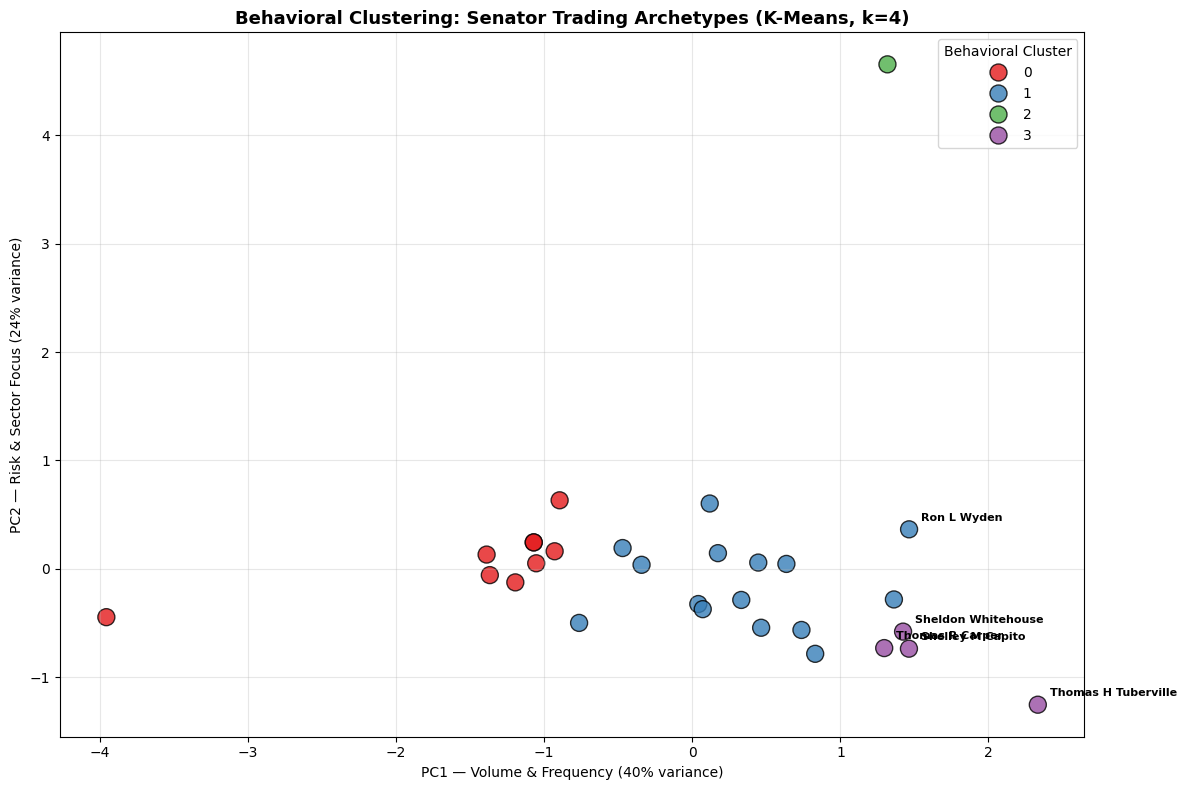


[Top 10 senators by options usage]
                   Senator  Cluster  Total_Trades  Options_Ratio  Tech_Ratio
A. Mitchell McConnell, Jr.        1            27            0.0    0.000000
          Markwayne Mullin        1           148            0.0    0.141892
           William Cassidy        1           187            0.0    0.117647
                Tina Smith        0            20            0.0    0.000000
           Thomas R Tillis        0            62            0.0    0.000000
           Thomas R Carper        3           499            0.0    0.082164
       Thomas H Tuberville        3          1094            0.0    0.145338
           Tammy Duckworth        0            12            0.0    0.083333
           Susan M Collins        1           139            0.0    0.028777
          Shelley M Capito        3           571            0.0    0.103327


In [9]:
# Beyond individual transactions, we construct a behavioral profile for each
# senator by aggregating their trading history. K-Means clustering then groups
# senators with similar trading patterns into behavioral archetypes.
#
# Features:
#   Total_Trades   — overall trading frequency (high frequency may indicate
#                    systematic exploitation of informational flow)
#   Buy_Ratio      — proportion of purchases (directional bias)
#   Avg_Volume     — mean transaction size (exposure scale)
#   Options_Ratio  — share of option transactions (highest timing precision required)
#   Tech_Ratio     — concentration in technology sector (regulated by key committees)
#
# We reduce to 2D with PCA for visualization, which preserves the maximum
# variance in the data while making the clusters interpretable visually.
# =============================================================================

print("\n--- STEP 9: BEHAVIORAL CLUSTERING (K-MEANS + PCA) ---")

TECH_TICKERS = {
    'AAPL', 'MSFT', 'NVDA', 'INTC', 'QCOM', 'PYPL',
    'GOOGL', 'AMZN', 'META', 'TSLA', 'AMD', 'CRM', 'NFLX'
}

senator_behaviors = []

for (fname, lname), group in df.groupby(['first_name', 'last_name']):
    n_trades = len(group)

    # We require at least 5 trades to construct a meaningful behavioral profile;
    # fewer observations would produce unreliable aggregate statistics
    if n_trades < 5:
        continue

    options_flag = group['transaction'].astype(str).str.lower().str.contains(
        'option|call|put', na=False
    )

    senator_behaviors.append({
        'Senator'     : f"{fname} {lname}",
        'Total_Trades': n_trades,
        'Buy_Ratio'   : group['is_buy_order'].mean(),
        'Avg_Volume'  : group['estimated_volume'].mean(),
        'Options_Ratio': options_flag.sum() / n_trades,
        'Tech_Ratio'  : group['ticker'].isin(TECH_TICKERS).sum() / n_trades,
    })

behavior_df = pd.DataFrame(senator_behaviors)

if len(behavior_df) >= 4:
    CLUSTER_FEATURES = ['Total_Trades', 'Buy_Ratio', 'Avg_Volume', 'Options_Ratio', 'Tech_Ratio']

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(behavior_df[CLUSTER_FEATURES])

    # K=4 produces interpretable archetypes: passive holders, active buyers,
    # options traders, and tech concentrators. Optimal k can be validated
    # with the elbow method if the dataset is large enough.
    kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
    behavior_df['Cluster'] = kmeans.fit_predict(X_scaled)

    print("[Cluster Profiles — Mean Feature Values]")
    print(behavior_df.groupby('Cluster')[CLUSTER_FEATURES].mean().round(3))

    # PCA for visualization: we reduce the 5-dimensional feature space
    # to 2 principal components that capture the most variance
    pca    = PCA(n_components=2)
    pca_2d = pca.fit_transform(X_scaled)
    behavior_df['PCA_1'] = pca_2d[:, 0]
    behavior_df['PCA_2'] = pca_2d[:, 1]

    print(f"\nPCA explained variance: PC1={pca.explained_variance_ratio_[0]:.1%}, "
          f"PC2={pca.explained_variance_ratio_[1]:.1%} "
          f"(total={sum(pca.explained_variance_ratio_):.1%})")

    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        data=behavior_df, x='PCA_1', y='PCA_2', hue='Cluster',
        palette='Set1', s=150, alpha=0.8, edgecolor='black', ax=ax
    )

    # Label only the most active or options-heavy traders to avoid clutter
    for _, r in behavior_df.iterrows():
        if r['Total_Trades'] > behavior_df['Total_Trades'].quantile(0.85) or \
           r['Options_Ratio'] > 0.15:
            ax.text(r['PCA_1'] + 0.08, r['PCA_2'] + 0.08, r['Senator'],
                    fontsize=8, fontweight='bold')

    ax.set_title('Behavioral Clustering: Senator Trading Archetypes (K-Means, k=4)',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel(f'PC1 — Volume & Frequency ({pca.explained_variance_ratio_[0]:.0%} variance)')
    ax.set_ylabel(f'PC2 — Risk & Sector Focus ({pca.explained_variance_ratio_[1]:.0%} variance)')
    ax.legend(title='Behavioral Cluster')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("\n[Top 10 senators by options usage]")
    print(behavior_df[['Senator', 'Cluster', 'Total_Trades', 'Options_Ratio', 'Tech_Ratio']]
          .sort_values('Options_Ratio', ascending=False).head(10).to_string(index=False))

else:
    print("Not enough senators with ≥5 trades to run clustering.")


--- STEP 12: ISOLATION FOREST ANOMALY DETECTION ---
Isolation Forest flagged 44 anomalies out of 4476 transactions (0.98%).

TOP ANOMALIES DETECTED BY ISOLATION FOREST:

  Senator: Susan M Collins              | Asset: MMM    | BUY  | Volume: $37,500,000 | Alpha: -1.04%
  Senator: Mark R Warner               | Asset: CHTR   | SELL | Volume: $ 3,000,000 | Alpha: +2.19%
  Senator: William F Hagerty, IV          | Asset: DDOG   | SELL | Volume: $ 3,000,000 | Alpha: -4.41%
  Senator: Mark R Warner               | Asset: HALO   | SELL | Volume: $   750,000 | Alpha: +4.95%
  Senator: John W Hickenlooper         | Asset: NVDA   | SELL | Volume: $   750,000 | Alpha: +23.80%
  Senator: Tina Smith                | Asset: PODD   | SELL | Volume: $   375,000 | Alpha: +36.78%
  Senator: John W Hickenlooper         | Asset: AAPL   | SELL | Volume: $   375,000 | Alpha: +5.96%
  Senator: John Hoeven               | Asset: KHC    | SELL | Volume: $   375,000 | Alpha: +9.46%
  Senator: Mark R Warner   

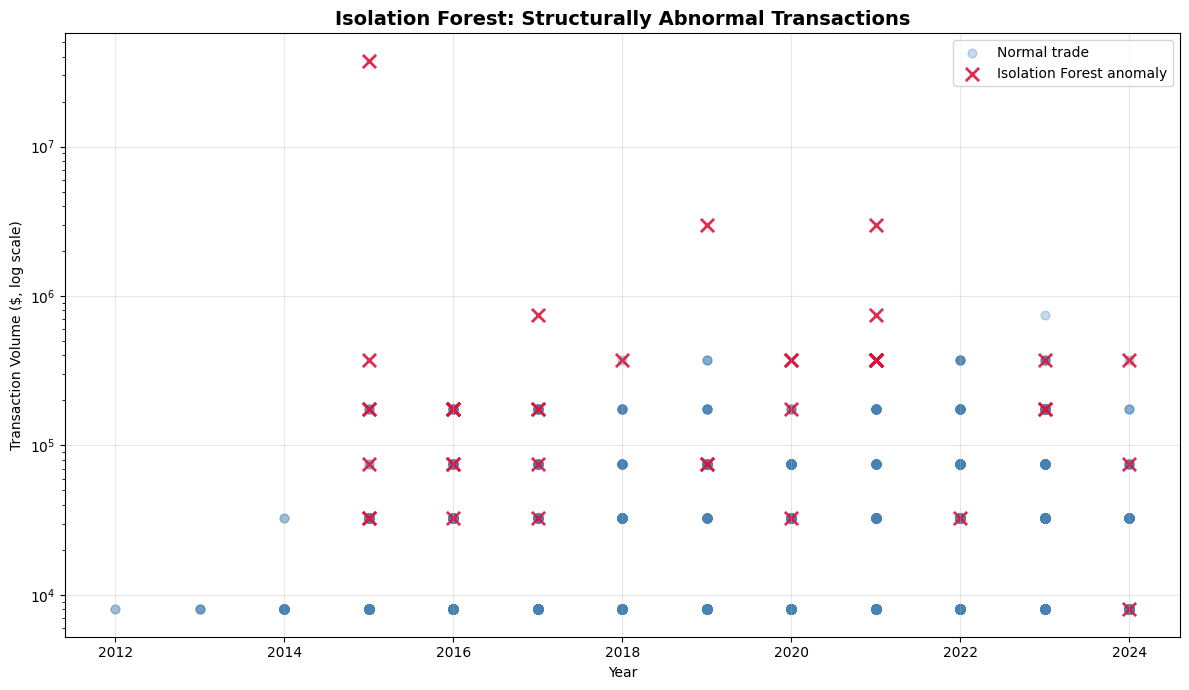

In [10]:
# Isolation Forest detects anomalies by measuring how quickly an observation
# can be "isolated" from the rest of the dataset through random partitioning.
# Outliers require fewer partitions because they occupy sparse regions of the
# feature space. This is particularly well-suited to our problem because we
# do not need labeled data -- the algorithm flags structurally unusual trades
# regardless of their realized outcome.
#
# We use a richer feature set than volume alone, including timing features
# and the realized alpha, to capture the full geometry of abnormal trading.
# contamination=0.01 targets the most extreme 1% of transactions.
# =============================================================================

print("\n--- STEP 12: ISOLATION FOREST ANOMALY DETECTION ---")

ISO_FEATURES = [
    'log_volume',    # transaction scale
    'year',          # temporal shift in regulatory environment
    'month',         # seasonality
    'is_buy_order',  # direction
    'is_proxy',      # account distancing behavior
    'is_option',     # instrument precision
    'alpha',         # realized market-adjusted return (post-trade signal)
]

iso_df = df.dropna(subset=ISO_FEATURES).copy()

if len(iso_df) > 10:
    scaler_iso    = StandardScaler()
    X_iso         = scaler_iso.fit_transform(iso_df[ISO_FEATURES])

    iso_forest = IsolationForest(
        n_estimators=200,
        contamination=0.01,   # target the most extreme 1% of observations
        random_state=42
    )
    iso_df['Anomaly_Score'] = iso_forest.fit_predict(X_iso)

    # fit_predict returns -1 for anomalies, +1 for normal observations
    iso_outliers = iso_df[iso_df['Anomaly_Score'] == -1]
    print(f"Isolation Forest flagged {len(iso_outliers)} anomalies out of {len(iso_df)} transactions "
          f"({100*len(iso_outliers)/len(iso_df):.2f}%).\n")

    top_iso_anomalies = iso_outliers.sort_values('log_volume', ascending=False).head(15)

    print("TOP ANOMALIES DETECTED BY ISOLATION FOREST:\n")
    for _, row in top_iso_anomalies.iterrows():
        direction = "BUY" if row['is_buy_order'] == 1 else "SELL"
        print(
            f"  Senator: {row['first_name']} {row['last_name']:<20} "
            f"| Asset: {row['ticker']:<6} "
            f"| {direction:<4} "
            f"| Volume: ${row['estimated_volume']:>10,.0f} "
            f"| Alpha: {row['alpha']:+.2f}%"
        )

    # Visualize the anomaly landscape
    fig, ax = plt.subplots(figsize=(12, 7))
    normal   = iso_df[iso_df['Anomaly_Score'] ==  1]
    abnormal = iso_df[iso_df['Anomaly_Score'] == -1]

    ax.scatter(normal['year'],   normal['estimated_volume'],
               c='steelblue', alpha=0.3, s=40,  label='Normal trade')
    ax.scatter(abnormal['year'], abnormal['estimated_volume'],
               c='crimson',    alpha=0.9, s=90, marker='x', linewidths=2,
               label='Isolation Forest anomaly')

    ax.set_yscale('log')
    ax.set_xlabel('Year')
    ax.set_ylabel('Transaction Volume ($, log scale)')
    ax.set_title('Isolation Forest: Structurally Abnormal Transactions',
                 fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

else:
    print("Insufficient data for Isolation Forest after dropping NaN alpha values.")
    top_iso_anomalies = pd.DataFrame()

In [12]:
import yfinance as yf
import pandas as pd
import numpy as np

print("\n--- STEP 13: VERIFYING ISOLATION FOREST ANOMALIES WITH POST-TRADE PRICES ---")

ml_pl_results = []

# Veri formatı farklılıklarını (Series/DataFrame) düzelten yardımcı fonksiyon
def get_scalar(val):
    if isinstance(val, pd.Series):
        return float(val.iloc[0])
    elif isinstance(val, pd.DataFrame):
        return float(val.iloc[0, 0])
    return float(val)

if 'top_iso_anomalies' in globals() and not top_iso_anomalies.empty:
    for _, row in top_iso_anomalies.iterrows():
        ticker     = str(row['ticker']).strip()
        trade_date = pd.to_datetime(row['transaction_date'])
        is_buy     = row['is_buy_order'] == 1
        volume     = float(row['estimated_volume'])
        senator    = f"{row['first_name']} {row['last_name']}"

        try:
            stock_data = yf.download(
                ticker,
                start=trade_date - pd.Timedelta(days=2),
                end=trade_date   + pd.Timedelta(days=35),
                progress=False
            )

            if not stock_data.empty and len(stock_data) >= 2:
                stock_data.index = stock_data.index.tz_localize(None).normalize()

                entry_rows = stock_data[stock_data.index >= trade_date]
                if entry_rows.empty:
                    continue
                
                # GÜVENLİ VERİ ÇEKME (get_scalar eklendi)
                entry_price = get_scalar(entry_rows['Close'].iloc[0])

                target_date = trade_date + pd.Timedelta(days=30)
                exit_rows   = stock_data[stock_data.index >= target_date]
                
                if not exit_rows.empty:
                    exit_price = get_scalar(exit_rows['Close'].iloc[0])
                else:
                    exit_price = get_scalar(stock_data['Close'].iloc[-1])

                change_pct = ((exit_price - entry_price) / entry_price) * 100

                if is_buy:
                    outcome    = "Profit" if change_pct > 0 else "Loss"
                    impact_usd = volume * (change_pct / 100)
                else:
                    outcome    = "Loss Avoided" if change_pct < 0 else "Missed Gain"
                    impact_usd = volume * abs(change_pct) / 100 if change_pct < 0 \
                                 else -volume * change_pct / 100

                ml_pl_results.append({
                    'Senator'          : senator,
                    'Asset'            : ticker,
                    'Type'             : "BUY" if is_buy else "SELL",
                    'Volume_$'         : volume,
                    '30d_Change_%'     : round(change_pct, 2),
                    'Outcome'          : outcome,
                    'Financial_Impact_$': round(impact_usd, 2),
                })
        except Exception as e:
            continue

    if ml_pl_results:
        verify_df = pd.DataFrame(ml_pl_results).sort_values('Financial_Impact_$', ascending=False)
        print(verify_df.to_string(index=False))
    else:
        print("Could not retrieve price data for anomaly verification. All attempts failed inside try-except.")
else:
    print("No anomalies to verify. Check if top_iso_anomalies exists in this notebook.")


--- STEP 13: VERIFYING ISOLATION FOREST ANOMALIES WITH POST-TRADE PRICES ---
              Senator Asset Type   Volume_$  30d_Change_%      Outcome  Financial_Impact_$
William F Hagerty, IV  DDOG SELL  3000000.5         -4.28 Loss Avoided           128403.50
  John W Hickenlooper  PYPL SELL   375000.5        -22.47 Loss Avoided            84248.63
  John W Hickenlooper GOOGL SELL   375000.5         -1.70 Loss Avoided             6390.84
  John W Hickenlooper  MSFT SELL   375000.5          0.40  Missed Gain            -1495.80
          John Hoeven   WTW SELL   375000.5          0.86  Missed Gain            -3214.28
        Mark R Warner  ROAD SELL   375000.5          1.44  Missed Gain            -5413.99
  John W Hickenlooper  AMZN SELL   375000.5          5.61  Missed Gain           -21031.60
  John W Hickenlooper  AAPL SELL   375000.5          7.13  Missed Gain           -26720.43
          John Hoeven   KHC SELL   375000.5         11.08  Missed Gain           -41564.99
        Mark